In [2]:
import pandas as pd

df1 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Internship\Market_Price Analysis\apmc_rajkot_rates.csv")
print("\n")

df2 = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Internship\Market_Price Analysis\apmc_rajkot.csv")


print(df1.head())
print(df2.head())

print(df1.info())
print(df2.info())




         date      id jansi_type jansi_english_name jansi_gujarati_name  \
0  02/01/2026  107337      grain        Cotton B.T.         કપાસ બી.ટી.   
1  02/01/2026  107338      grain       Wheat Lokvan           ઘઉં લોકવન   
2  02/01/2026  107339      grain        Wheat Tukda           ઘઉં ટુકડા   
3  02/01/2026  107340      grain              Bajri               બાજરી   
4  02/01/2026  107341      grain              Tuver               તુવેર   

   arrival  lowrate  highrate  
0     2600     1310      1567  
1       80      505       530  
2      700      510       606  
3       34      300       400  
4      220      930      1600  
         date     id jansi_type jansi_english_name jansi_gujarati_name  \
0  01/01/2025  87411      grain        Cotton B.T.         કપાસ બી.ટી.   
1  01/01/2025  87412      grain       Wheat Lokvan           ઘઉં લોકવન   
2  01/01/2025  87413      grain        Wheat Tukda           ઘઉં ટુકડા   
3  01/01/2025  87414      grain        Jowar White         

In [3]:
# change data type of date str to date 

df1['date'] = pd.to_datetime(df1['date'], dayfirst=True)
df2['date'] = pd.to_datetime(df2['date'], dayfirst=True)

df1['month'] = df1['date'].dt.month
df1['year'] = df1['date'].dt.year

df2['month'] = df2['date'].dt.month
df2['year'] = df2['date'].dt.year



In [4]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()

df1.columns = df1.columns.str.lower().str.strip()
df2.columns = df2.columns.str.lower().str.strip()

df1['avg_rate'] = (df1['lowrate'] + df1['highrate']) / 2
df2['avg_rate'] = (df2['lowrate'] + df2['highrate']) / 2
print(df1['avg_rate'].head())
print(df2['avg_rate'].head())


0    1438.5
1     517.5
2     558.0
3     350.0
4    1265.0
Name: avg_rate, dtype: float64
0    1420.0
1     609.0
2     633.5
3     801.5
4     450.0
Name: avg_rate, dtype: float64


In [5]:
# Normalization 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df1[['arrival','avg_rate']] = scaler.fit_transform(df1[['arrival','avg_rate']])
df2[['arrival','avg_rate']] = scaler.fit_transform(df2[['arrival','avg_rate']])
print(df1['arrival'].head())

print(df1['avg_rate'].head())

0    0.152941
1    0.004706
2    0.041176
3    0.002000
4    0.012941
Name: arrival, dtype: float64
0    0.176768
1    0.055680
2    0.061004
3    0.033658
4    0.153957
Name: avg_rate, dtype: float64


In [6]:
# Which Jansi Type Has Highest Arrival
df1.groupby('jansi_type')['arrival'].sum().sort_values(ascending=False)
df2.groupby('jansi_type')['arrival'].sum().sort_values(ascending=False)
# WHICH JANSI ENG NAME HAVE HIGHEST AVG PRICE
df1.groupby('jansi_english_name')['avg_rate'].sum().sort_values(ascending=False)
df2.groupby('jansi_english_name')['avg_rate'].sum().sort_values(ascending=False)


df1.groupby('jansi_english_name')['avg_rate'].sum().sort_values(ascending=False)
df2.groupby('jansi_english_name')['avg_rate'].sum().sort_values(ascending=False)

# monthly avg price
monthly_price = df1.groupby('month')['avg_rate'].mean()
print(monthly_price)

monthly_price = df2.groupby('month')['avg_rate'].mean()
print(monthly_price)





month
1    0.184344
Name: avg_rate, dtype: float64
month
1     0.130994
2     0.124794
3     0.116662
4     0.128877
5     0.110418
6     0.123650
7     0.126169
8     0.120468
9     0.130459
10    0.127248
11    0.140285
12    0.141263
Name: avg_rate, dtype: float64


Top 5 Low by avg Price  jansi_english_name
Cabbage        0.005878
Papaya         0.007524
Green Corn     0.008387
Onion          0.009491
Water Melon    0.014814
Name: avg_rate, dtype: float64


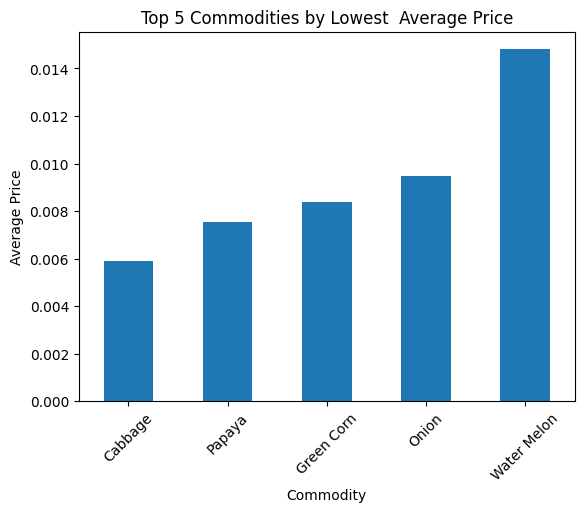

Top 5 by Highest Avg Price  jansi_english_name
Rajkoo Bee      0.571387
Sesmum-Black    0.358287
Cummin          0.346413
kalonji         0.336812
Seasmum         0.169577
Name: avg_rate, dtype: float64


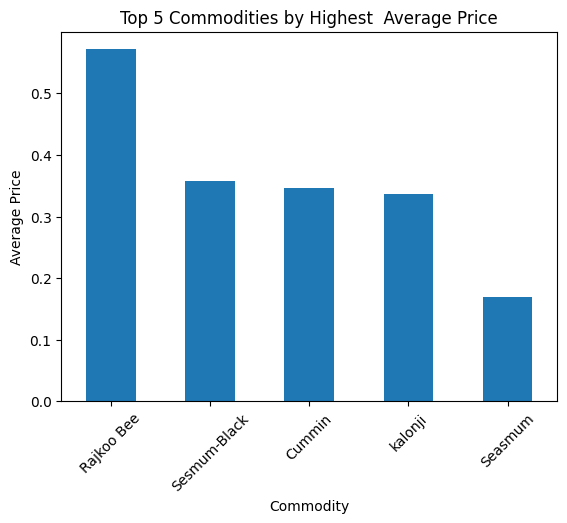

In [7]:
import matplotlib.pyplot as plt

monthly_avg = df2.groupby(
    ['month', 'jansi_english_name']
)['avg_rate'].mean().reset_index()
import matplotlib.pyplot as plt

"""pivot_table = monthly_avg.pivot_table(
    index='month',
    columns='jansi_english_name',
    values='avg_rate'
)

plt.figure()
avg_price.plot(kind='bar')
plt.title("Average Price per jansi_english_name (2025-26)")
plt.xlabel("Commodity")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()"""

top5 = (
    df2
    .groupby('jansi_english_name')['avg_rate']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
top5_chepest= (
    df2
    .groupby('jansi_english_name')['avg_rate']
    .mean()
    .sort_values(ascending=True)
    .head(5)
)

print("Top 5 Low by avg Price ",top5_chepest)
plt.figure()
top5_chepest.plot(kind='bar')
plt.title("Top 5 Commodities by Lowest  Average Price")
plt.xlabel("Commodity")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()



print("Top 5 by Highest Avg Price ",top5)
plt.figure()
top5.plot(kind='bar')
plt.title("Top 5 Commodities by Highest  Average Price")
plt.xlabel("Commodity")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()







           arrival  avg_rate
arrival   1.000000 -0.023087
avg_rate -0.023087  1.000000


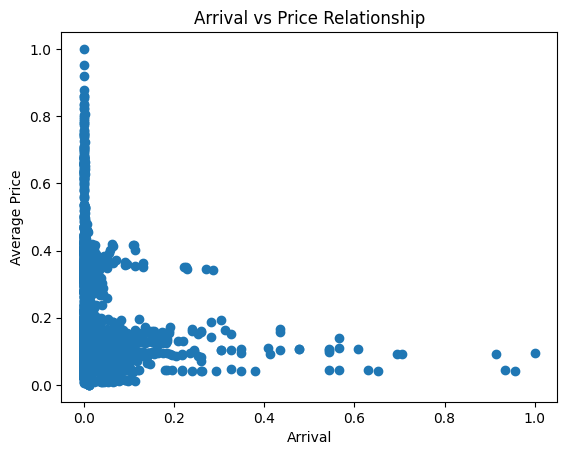

In [8]:
# price decrease when arrival increases

print(df2[['arrival','avg_rate']].corr())

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df2['arrival'], df2['avg_rate'])
plt.xlabel("Arrival")
plt.ylabel("Average Price")
plt.title("Arrival vs Price Relationship")
plt.show()

# Price is not strongly dependent on arrival alone. Other factors like demand, seasonality, and market conditions may influence price.
# Correlation value (-0.023) confirms a very weak relationship.

In [9]:
volatility = df2.groupby('jansi_english_name')['avg_rate'].std().sort_values(ascending=False)

print(volatility.head(10))
# High std = high price fluctuation.

jansi_english_name
Rajkoo Bee      0.148594
Green Garlic    0.103813
Chillies        0.061299
Lemon           0.059493
Choli Shing     0.054463
Sesmum-Black    0.048970
Garlic          0.043536
kalonji         0.040192
Cluster Been    0.036830
Choli           0.034556
Name: avg_rate, dtype: float64


month
1     0.130994
2     0.124794
3     0.116662
4     0.128877
5     0.110418
6     0.123650
7     0.126169
8     0.120468
9     0.130459
10    0.127248
11    0.140285
12    0.141263
Name: avg_rate, dtype: float64


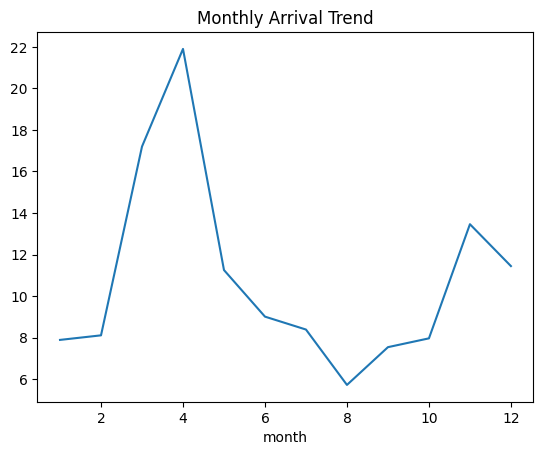

In [10]:
# Season analysis
seasonal = df2.groupby('month')['avg_rate'].mean()
print(seasonal)

monthly_arrival = df2.groupby('month')['arrival'].sum()

monthly_arrival.plot()
plt.title("Monthly Arrival Trend")
plt.show()
# we can see that month feb - may has highest avg selling 



In [11]:
# Price analysis
print(df2.groupby('jansi_english_name')['avg_rate'].mean().sort_values(ascending=False))
# Arrivle
print("\n")
df2.groupby('jansi_english_name')['arrival'].sum().sort_values(ascending=False)


jansi_english_name
Rajkoo Bee      0.571387
Sesmum-Black    0.358287
Cummin          0.346413
kalonji         0.336812
Seasmum         0.169577
                  ...   
Water Melon     0.014814
Onion           0.009491
Green Corn      0.008387
Papaya          0.007524
Cabbage         0.005878
Name: avg_rate, Length: 88, dtype: float64




jansi_english_name
Wheat Tukda        13.813478
Cotton B.T.        11.409130
Groundnut Small     9.197609
Groundnut Big       9.156130
Seasmum             8.242370
                     ...    
Linseed             0.006500
Val Papdi           0.006478
Gram Deshi          0.004348
Papaya              0.001522
Kankoda             0.000478
Name: arrival, Length: 88, dtype: float64

In [12]:
Q1 = df2['avg_rate'].quantile(0.25)
Q3 = df2['avg_rate'].quantile(0.75)
IQR = Q3 - Q1

outliers = df2[(df2['avg_rate'] < Q1 - 1.5*IQR) | 
               (df2['avg_rate'] > Q3 + 1.5*IQR)]

# print(outliers)
monthly_price = df2.groupby(['year','month'])['avg_rate'].mean().reset_index()

monthly_price['price_growth_%'] = monthly_price['avg_rate'].pct_change() * 100
print(monthly_price['price_growth_%'])


0           NaN
1     -4.213577
2     -6.516265
3     10.470064
4    -14.322375
5     11.983283
6      2.036944
7     -4.518555
8      8.293865
9     -2.461432
10    10.245536
11     0.696964
12     5.470462
Name: price_growth_%, dtype: float64


<Figure size 1200x600 with 0 Axes>

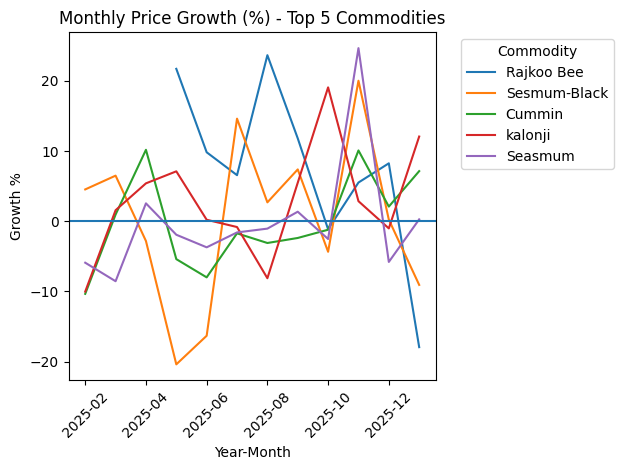

In [13]:
import matplotlib.pyplot as plt

monthly_price = df2.groupby(
    ['year', 'month', 'jansi_english_name'],
    as_index=False
)['avg_rate'].mean()

monthly_price = monthly_price.sort_values(
    ['jansi_english_name', 'year', 'month']
)

monthly_price['price_growth_%'] = (
    monthly_price
    .groupby('jansi_english_name')['avg_rate']
    .pct_change() * 100
)

monthly_price = monthly_price.dropna(subset=['price_growth_%'])

monthly_price['year_month'] = (
    monthly_price['year'].astype(str) + '-' +
    monthly_price['month'].astype(str).str.zfill(2)
)

pivot_growth = monthly_price.pivot_table(
    index='year_month',
    columns='jansi_english_name',
    values='price_growth_%'
)

top5 = (
    monthly_price.groupby('jansi_english_name')['avg_rate']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

pivot_growth_top5 = pivot_growth[top5]

plt.figure(figsize=(12,6))
pivot_growth_top5.plot()

plt.axhline(0)
plt.title("Monthly Price Growth (%) - Top 5 Commodities")
plt.xlabel("Year-Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.legend(title="Commodity", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()



In [14]:
# Name of Commodities that price Never Decreased 

non_decreasing = (
    monthly_price
    .groupby('jansi_english_name')['price_growth_%']
    .apply(lambda x: (x >= 0).all())
)
print(non_decreasing)



vatana_avg_price = (
    df2[df2['jansi_english_name'] == 'Vatana']
    .groupby(['year', 'month'], as_index=False)['avg_rate']
    .mean()
    .sort_values(['year', 'month'])
)

print(vatana_avg_price)
# we can see that vatanas price is non decresed also it is only available in Season month Feb -May
# print(df2)


jansi_english_name
Asario          False
Bajri           False
Beet            False
Bitter Gourd    False
Bottle Gourd    False
                ...  
Vatana           True
Water Melon     False
Wheat Lokvan    False
Wheat Tukda     False
kalonji         False
Name: price_growth_%, Length: 83, dtype: bool
   year  month  avg_rate
0  2025      3  0.100796
1  2025      4  0.110986
2  2025      5  0.131364


In [15]:
print(df2.columns)
df2.to_csv("updated_original_data.csv", index=False)



Index(['date', 'id', 'jansi_type', 'jansi_english_name', 'jansi_gujarati_name',
       'arrival', 'lowrate', 'highrate', 'month', 'year', 'avg_rate'],
      dtype='str')
